<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

Explore examples PyTorch end-to-end workflow.

In [14]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making prediction and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making prediction and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [15]:
import torch
from torch import nn # nn contains all pf PyTorch's building blocks for neural network
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.9.0+cu126'

## 1. Data (preparing and loading)

Data can be almost anything in machine learning

* Excel spreadsheet
* Image of any kind
* Videos
* Audio
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.


We'll use a linear regression ofrmula to make a straight line with *known* parameters.

In [16]:
 # Create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [17]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

1. Trainint se (course materials - model learns pattern here)
2. Validation set (pratice exam - tune model patterns)
3. Test set (final exam - see if the model is ready for the wild)

Generalization is the ability for a machine learning model to perfrom well on data it hasn't seen before.

In [18]:
# Create a train-test split

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in

"Visualize, visualize, visualize!"

In [19]:
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
  """
  Plots trianing data, test data, and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="r", s=4, label="Testing data")

  # Are there predictions?
  if predictions is not None:
    # PLot predictions if they exsit
    plt.scatter(test_data, predictions, c="green", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})

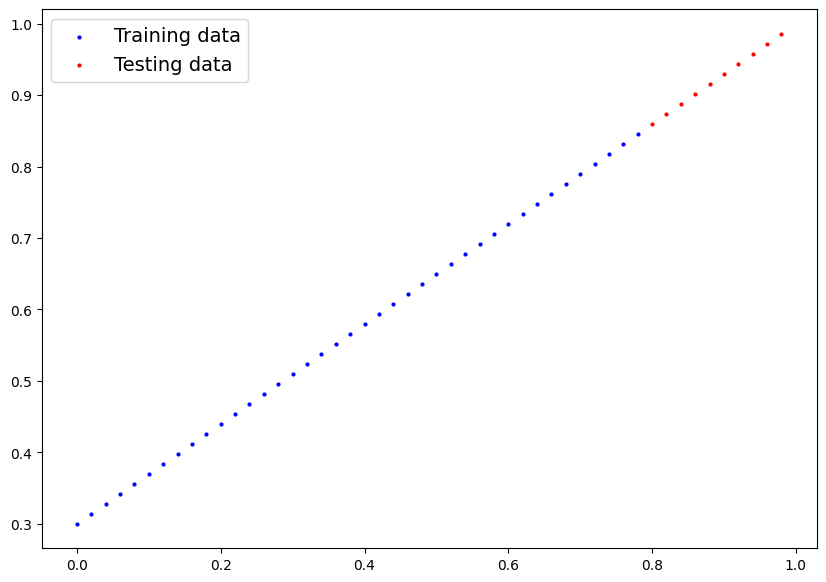

In [20]:
plot_predictions()

## 2. Build model

Our first PyTorch model!

What our model does:
* Starts with random values (weight and bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [21]:
from torch import nn

# Creata a linear regression model class

class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherit from nn.module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
    # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias # linear regression formula


### PyTorch model buidling essentials

* torch.nn - contains of the buidlngs for computational graphs
* troch.nn.Paramater - what paramaters should our model try and learn, often a PyTorch layer from torch.nn will set these for us

* torch.nn.Module - The base class for all NN modules, if you subclass iy, you should overwrite forward()
* torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defies what happen in forward computation.

### Checking the contents of our PyTorch  code

Now we've created a model. let's see what's inside...

So we can check our model parameters or what's inside our model uisng `.Paramaters()`

In [22]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [23]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [24]:
weight, bias

(0.7, 0.3)

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`

When we pass data trhough our model, it's going to run it through the forward() method.

In [25]:
# Make predicttion with model
with torch.inference_mode():
  y_preds = model_0(X_test)

# y_preds

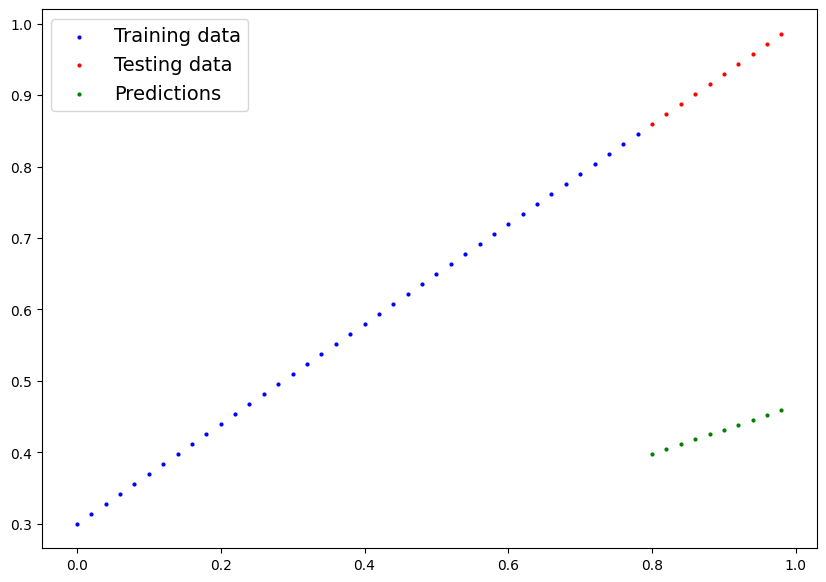

In [26]:
plot_predictions(predictions=y_preds)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* paramaters to some *
known* paramaters

From poor representation to a better representation of the data.

One way to measure how poor or how wrong your models predictions are to use loss function.

* Note: Loss function may also be called cost function or criterion in different areaas. For our case, we're going to refer to it as a loss function.

Things we need to train:

* **Loss function:** A function to measure how wrong your model's predictio are to the ideal output, lower is better.
* **Optimizer:** Takes into account the loss of a model and adjucts the model's parameters (e.g. weight and bias) to improve the loss fucntion.

And specifically for PyTorch we need:
* A training loop
* A testing loop

In [27]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [28]:
# Check out our model's paramaters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [29]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # learning rate = we can set it

### Building a training and a testing loop in PyTorch

A couple of thinsg we need in a training loop:

0. Loop through the data.
1. Forward pass (this involves data moving trhough our model's `forward` functions to make predictions on data - also called forward porpagation.
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad.
4. Loss backward - move backwards through the network to calculate the gradients of each of paramaters of our model with respect to the loss (**backpropagation**)
.
5. Optimizer step - use the optimizer to adjust and imporve the loss (**gradient descent**).

In [30]:
with torch.no_grad():
  model_0.parameters()

In [31]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [32]:
torch.manual_seed(42)

# An epoch is one loop through the data... (this is a hyperparamater)
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

# Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model_0.train() # train mode in PyTorch sets all paramaters that require gradients to require gradients

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Loss function
  loss = loss_fn(y_pred, y_train) # calculate the difference between prediction and real
  # print(f"Loss : {loss}")
  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Step the optimizer (preform gradient descent)
  optimizer.step()

  # Testing
  model_0.eval() # turn off gradient training. Not needed in testing code
  with torch.inference_mode():
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. Caluculate the loss
    test_loss = loss_fn(test_pred, y_test)
  if epoch % 10 ==0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Train loss: {loss} | Test loss {test_loss}")

print(model_0.state_dict())

Epoch: 0 | Train loss: 0.31288138031959534 | Test loss 0.48106518387794495
Epoch: 10 | Train loss: 0.1976713240146637 | Test loss 0.3463551998138428
Epoch: 20 | Train loss: 0.08908725529909134 | Test loss 0.21729660034179688
Epoch: 30 | Train loss: 0.053148526698350906 | Test loss 0.14464017748832703
Epoch: 40 | Train loss: 0.04543796554207802 | Test loss 0.11360953003168106
Epoch: 50 | Train loss: 0.04167863354086876 | Test loss 0.09919948130846024
Epoch: 60 | Train loss: 0.03818932920694351 | Test loss 0.08886633068323135
Epoch: 70 | Train loss: 0.03476089984178543 | Test loss 0.0805937647819519
Epoch: 80 | Train loss: 0.03132382780313492 | Test loss 0.07232122868299484
Epoch: 90 | Train loss: 0.02788739837706089 | Test loss 0.06473556160926819
Epoch: 100 | Train loss: 0.024458957836031914 | Test loss 0.05646304413676262
Epoch: 110 | Train loss: 0.021020207554101944 | Test loss 0.04819049686193466
Epoch: 120 | Train loss: 0.01758546568453312 | Test loss 0.04060482233762741
Epoch: 130

/tmp/ipython-input-1289241880.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")


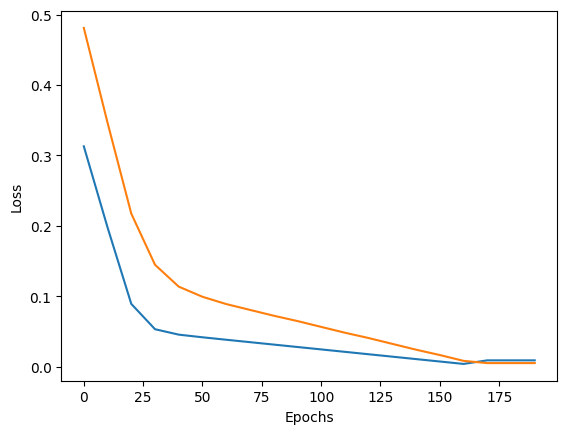

In [33]:
import numpy as np

plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label="Test loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

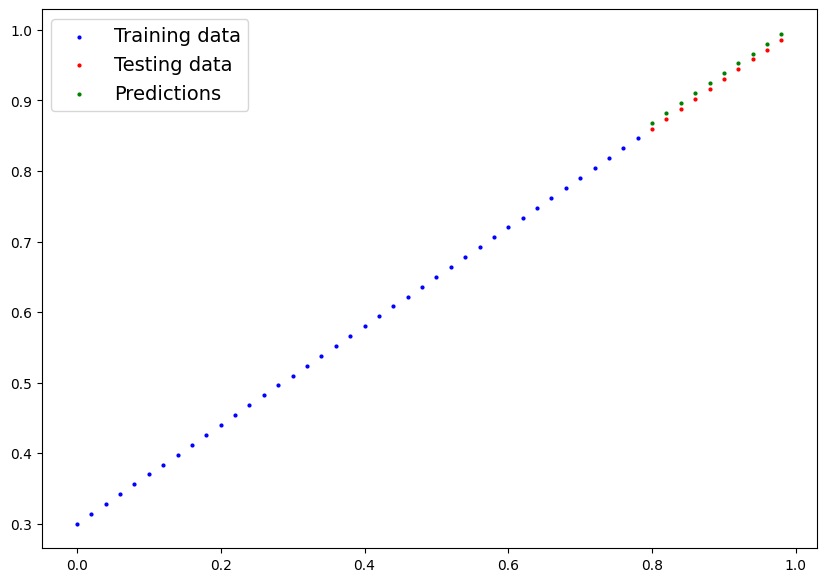

In [34]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

plot_predictions(predictions=y_preds_new)

## Saving a model in Python

Three are 3 main methods you should know for saving and loading in PyTorch.

1. `torch.save()` - allow you save a PyTorch objwct in Python's pickle format.
2. `torch.load()` - allows you to load a saved PyTorch object.
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary.

In [35]:
# Saving our PyTorch model

from pathlib import Path

# 1. Create a model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving the model to: {MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

Saving the model to: models/01_pytorch_workflow_model_0.pt


In [36]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Dec  4 08:06 01_pytorch_workflow_model_0.pt


## Loading a PyTorch model

Since we save our model's `state_dict()` we'll create a new instance of our model class and load the saved `state_dict()` into that

In [37]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [38]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [39]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [40]:
# Make some predictions with our loaded mode
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [41]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [42]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [43]:
## 6. Putting it all together
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check version
torch.__version__

'2.9.0+cu126'

Create device-agnostic code.

If we have GPU, the code will use it

In [44]:
# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [45]:
!nvidia-smi

Thu Dec  4 08:06:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [46]:
# Data y = weight * X + bias
weight = 3
bias   = 5

X = torch.arange(0, 1, 0.001).unsqueeze(dim=1)
y = weight * X + bias + torch.rand(size=X.size())

# Train-test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test,  y_test  = X[train_split:], y[train_split:]

# Building the linear model
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear()
    self.linear_layer = nn.Linear(in_features=1, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set manual seed
torch.manual_seed(67)
model_1 = LinearRegressionModelV2()

# Set device
model_1.to(device)

# Loss function
loss_fn = nn.L1Loss()

# Optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

# Training loop
torch.manual_seed(67)
epochs = 10000

# Device agnostic code for data
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # Forward pass
  y_pred = model_1(X_train)

  # Loss
  loss = loss_fn(y_pred, y_train)

  # Zero grad
  optimizer.zero_grad()

  # Backpropagation
  loss.backward()

  # Optimize step
  optimizer.step()

  # Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  # Print process
  if epoch % 50 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss} ")

print(model_1.state_dict())


Epoch: 0 | Loss: 6.759106159210205 | Test loss: 8.033512115478516 
Epoch: 50 | Loss: 6.1793060302734375 | Test loss: 7.353836536407471 
Epoch: 100 | Loss: 5.599506855010986 | Test loss: 6.674161434173584 
Epoch: 150 | Loss: 5.019707202911377 | Test loss: 5.994487762451172 
Epoch: 200 | Loss: 4.439908504486084 | Test loss: 5.314815521240234 
Epoch: 250 | Loss: 3.86011004447937 | Test loss: 4.635143756866455 
Epoch: 300 | Loss: 3.2803118228912354 | Test loss: 3.9554717540740967 
Epoch: 350 | Loss: 2.7005133628845215 | Test loss: 3.2757997512817383 
Epoch: 400 | Loss: 2.1207146644592285 | Test loss: 2.596127510070801 
Epoch: 450 | Loss: 1.5409107208251953 | Test loss: 1.916450023651123 
Epoch: 500 | Loss: 0.9611002802848816 | Test loss: 1.2367660999298096 
Epoch: 550 | Loss: 0.4094078838825226 | Test loss: 0.5749038457870483 
Epoch: 600 | Loss: 0.27075162529945374 | Test loss: 0.30883970856666565 
Epoch: 650 | Loss: 0.2592281997203827 | Test loss: 0.26164543628692627 
Epoch: 700 | Loss: 0

ValueError: x and y must be the same size

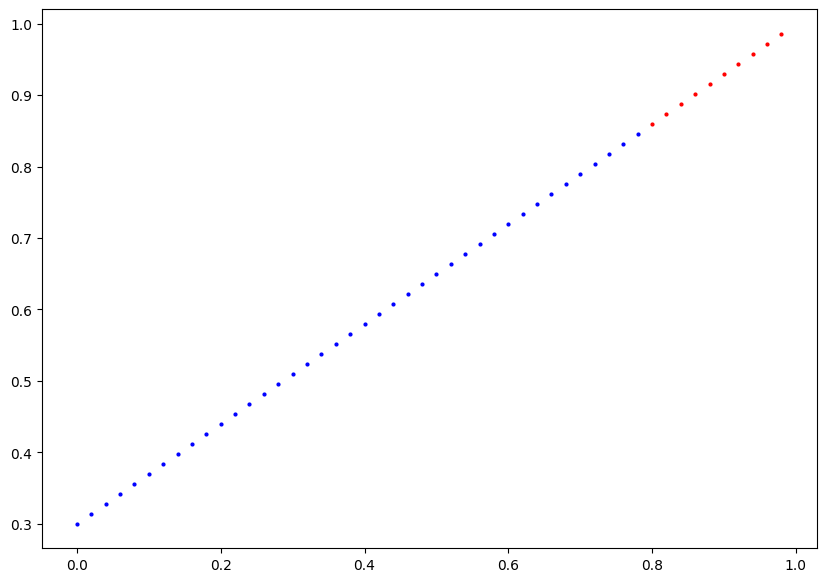

In [47]:
# Evaluate
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)

plot_predictions(predictions=y_preds.cpu())

In [ ]:
!pip install pathlib

In [50]:
# Save model
from pathlib import Path

# Directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save path
MODEL_NAME = "01_pytroch_workflow_mode_1.pt"
MODEL_SAVE_NAME = MODEL_PATH / MODEL_NAME
print(f"Sabing model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Sabing model to: models/01_pytorch_workflow_model_0.pt


In [58]:
# Load model

loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_1.to(device)
loaded_model_1.state_dict()

# Evaluate
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_pred = loaded_model_1(X_test)

loaded_model_1_pred

tensor([[7.9017],
        [7.9048],
        [7.9079],
        [7.9110],
        [7.9141],
        [7.9173],
        [7.9204],
        [7.9235],
        [7.9266],
        [7.9297],
        [7.9328],
        [7.9359],
        [7.9391],
        [7.9422],
        [7.9453],
        [7.9484],
        [7.9515],
        [7.9546],
        [7.9577],
        [7.9609],
        [7.9640],
        [7.9671],
        [7.9702],
        [7.9733],
        [7.9764],
        [7.9795],
        [7.9827],
        [7.9858],
        [7.9889],
        [7.9920],
        [7.9951],
        [7.9982],
        [8.0013],
        [8.0045],
        [8.0076],
        [8.0107],
        [8.0138],
        [8.0169],
        [8.0200],
        [8.0231],
        [8.0263],
        [8.0294],
        [8.0325],
        [8.0356],
        [8.0387],
        [8.0418],
        [8.0449],
        [8.0480],
        [8.0512],
        [8.0543],
        [8.0574],
        [8.0605],
        [8.0636],
        [8.0667],
        [8.0698],
        [8